In [ ]:
import os
import time
import requests
import joblib
import pandas as pd
import tldextract
from rapidfuzz import fuzz

# ==========================================
# 1. INITIALIZATION & FILE PATHS
# ==========================================
INPUT_UNLABELED_FILE = "unlabeled_5500_companies.csv"  # <-- Make sure this matches your exact file name!
OUTPUT_FINAL_PREDICTIONS = "final_company_websites_matched.csv"
MODEL_PATH = "company_predictor_RFmodel.joblib"       # <-- Updated to match your exact file name!

SERPER_API_KEY = "efa6cbe513613e548d0742a7e5cf6cab1ea82a01"
API_URL = "https://google.serper.dev/search"
SOCIAL_DOMAINS = ["linkedin", "facebook", "instagram", "twitter", "youtube", "justdial", "zaubacorp", "indiamart"]

# Load our machine learning brain
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"❌ Cannot find trained model binary at '{MODEL_PATH}'. Run Cell 4 first!")

clf = joblib.load(MODEL_PATH)
print("🧠 Trained Random Forest Model loaded into memory successfully.")

# Load input sheet
if not os.path.exists(INPUT_UNLABELED_FILE):
    raise FileNotFoundError(f"❌ Cannot find your file: '{INPUT_UNLABELED_FILE}'")

unlabeled_df = pd.read_csv(INPUT_UNLABELED_FILE)
unlabeled_df.columns = unlabeled_df.columns.str.strip()
total_records = len(unlabeled_df)

# Checkpoint system: load existing progress if it exists
if os.path.exists(OUTPUT_FINAL_PREDICTIONS):
    processed_df = pd.read_csv(OUTPUT_FINAL_PREDICTIONS)
    completed_queries = set(processed_df["query_name"].unique())
    final_output_rows = processed_df.to_dict(orient="records")
    print(f"🔄 Checkpoint found! Already completed {len(completed_queries)} / {total_records} companies. Resuming...")
else:
    completed_queries = set()
    final_output_rows = []

# ==========================================
# 2. MATCHING UTILITY FUNCTIONS
# ==========================================
def check_acronym_match(company_name, domain_str):
    name_str = str(company_name).strip().lower()
    dom_str = str(domain_str).strip().lower()
    for word in ["pvt", "ltd", "limited", "private", "inc", "corp", "co", "llp", "trust"]:
        name_str = name_str.replace(f" {word}", "")
    words = name_str.split()
    if len(words) < 2: return 0
    acronym = "".join([w[0] for w in words if w]).lower()
    if acronym and acronym in dom_str: return 1
    return 0

# ==========================================
# 3. PRODUCTION PIPELINE LOOP
# ==========================================
print(f"🚀 Processing pipeline live. Analyzing {total_records - len(completed_queries)} remaining companies...")

for i, row in unlabeled_df.iterrows():
    company_query = str(row["query_name"]).strip()
    
    # Skip if already done via checkpoint tracker
    if company_query in completed_queries:
        continue
        
    print(f"[{i+1}/{total_records}] 🔍 API Extraction & ML Scoring for: {company_query}")
    
    # --- Network/API Fetch Block ---
    headers = {'X-API-KEY': SERPER_API_KEY, 'Content-Type': 'application/json'}
    payload = {"q": company_query.lower(), "num": 3}
    
    max_retries = 3
    response = None
    for attempt in range(max_retries):
        try:
            response = requests.post(API_URL, headers=headers, json=payload, timeout=10)
            break
        except (requests.exceptions.ConnectionError, requests.exceptions.Timeout):
            if attempt < max_retries - 1:
                time.sleep(5)
            else:
                response = None

    if response is None or response.status_code != 200:
        print(f"⚠️ Skipping '{company_query}' due to persistent network or API limits.")
        continue
        
    json_data = response.json()
    organic_results = json_data.get("organic", [])
    
    candidate_links = [item.get("link") for item in organic_results if item.get("link")]
    unique_candidates = list(dict.fromkeys(candidate_links))[:3]
    
    if not unique_candidates:
        final_output_rows.append({
            "query_name": company_query,
            "matched_url": "NOT_FOUND",
            "confidence_score": 0.0
        })
        completed_queries.add(company_query)
        continue

    # --- Live Feature Engineering & Model Inference ---
    temp_features_list = []
    
    for idx, candidate_url in enumerate(unique_candidates):
        clean_domain = tldextract.extract(str(candidate_url)).domain
        similarity = fuzz.token_sort_ratio(company_query.lower(), clean_domain.lower())
        acronym_match = check_acronym_match(company_query, clean_domain)
        is_social = 1 if clean_domain in SOCIAL_DOMAINS else 0
        
        temp_features_list.append({
            "url": candidate_url,
            "features": [idx + 1, similarity, acronym_match, is_social]
        })
        
    feature_df = pd.DataFrame(
        [item["features"] for item in temp_features_list], 
        columns=["search_position", "clean_domain_similarity", "acronym_match", "is_socialmedia"]
    )
    
    # Predict probabilities instead of hard 1s and 0s
    probabilities = clf.predict_proba(feature_df)[:, 1]
    
    best_url = "NOT_FOUND"
    highest_conf = 0.0
    
    for idx, prob in enumerate(probabilities):
        if prob > highest_conf and prob >= 0.50:  # Must clear a 50% true certainty threshold
            highest_conf = prob
            best_url = temp_features_list[idx]["url"]
            
    final_output_rows.append({
        "query_name": company_query,
        "matched_url": best_url,
        "confidence_score": round(float(highest_conf), 4)
    })
    
    completed_queries.add(company_query)
    
    # Save checkpoint to file every 10 iterations
    if (len(completed_queries) % 10 == 0) or (len(completed_queries) == total_records):
        pd.DataFrame(final_output_rows).to_csv(OUTPUT_FINAL_PREDICTIONS, index=False)
        
    time.sleep(0.4) # Gentle rate limiter

print(f"\n🎉 Automation Complete! Final verified production sheet saved to '{OUTPUT_FINAL_PREDICTIONS}'")

In [6]:
import os
import requests
import joblib
import pandas as pd
import tldextract
from rapidfuzz import fuzz

def find_single_company_website(company_name):
    MODEL_PATH = "company_predictor_RFmodel.joblib"
    SERPER_API_KEY = "efa6cbe513613e548d0742a7e5cf6cab1ea82a01"
    API_URL = "https://google.serper.dev/search"
    SOCIAL_DOMAINS = ["linkedin", "facebook", "instagram", "twitter", "youtube", "justdial", "zaubacorp", "indiamart"]

    # 1. Load the frozen brain
    if not os.path.exists(MODEL_PATH):
        print(f"❌ Error: Model missing at {MODEL_PATH}")
        return

    clf = joblib.load(MODEL_PATH)
    
    # 2. Query Serper API for the top 3 candidate links
    print(f"🔍 Fetching live candidate URLs for: '{company_name}'...")
    headers = {'X-API-KEY': SERPER_API_KEY, 'Content-Type': 'application/json'}
    payload = {"q": company_name.lower(), "num": 3}
    
    try:
        response = requests.post(API_URL, headers=headers, json=payload, timeout=10)
        if response.status_code != 200:
            print("❌ API query failed.")
            return
    except Exception as e:
        print(f"❌ Connection error: {e}")
        return

    organic_results = response.json().get("organic", [])
    candidate_links = [item.get("link") for item in organic_results if item.get("link")]
    unique_candidates = list(dict.fromkeys(candidate_links))[:3]

    if not unique_candidates:
        print("❌ No search results found for this company.")
        return

    # Helper for acronym matching
    def get_acronym(name):
        name_clean = name.lower()
        for word in ["pvt", "ltd", "limited", "private", "inc", "corp", "co", "llp"]:
            name_clean = name_clean.replace(f" {word}", "")
        words = name_clean.split()
        if len(words) < 2: return 0
        return "".join([w[0] for w in words if w])

    # 3. Calculate features on the fly for the live links
    temp_features = []
    company_acronym = get_acronym(company_name)

    for idx, url in enumerate(unique_candidates):
        clean_domain = tldextract.extract(str(url)).domain
        similarity = fuzz.token_sort_ratio(company_name.lower(), clean_domain.lower())
        
        # Check acronym match
        acronym_match = 1 if (company_acronym and company_acronym in clean_domain.lower()) else 0
        is_social = 1 if clean_domain in SOCIAL_DOMAINS else 0
        
        temp_features.append({
            "url": url,
            "features": [idx + 1, similarity, acronym_match, is_social]
        })

    # 4. Ask the Random Forest model to predict probabilities
    feature_df = pd.DataFrame(
        [item["features"] for item in temp_features], 
        columns=["search_position", "clean_domain_similarity", "acronym_match", "is_socialmedia"]
    )
    
    probabilities = clf.predict_proba(feature_df)[:, 1]

    # 5. Evaluate the highest scorer
    best_url = "NOT_FOUND"
    highest_conf = 0.0

    print("\n🌲 Model Evaluation Breakdown:")
    print("-" * 50)
    for idx, prob in enumerate(probabilities):
        print(f"Position {idx+1}: {temp_features[idx]['url']}")
        print(f"      ↳ Features: {temp_features[idx]['features']}")
        print(f"      ↳ Model Confidence: {prob:.2%}")
        
        if prob > highest_conf and prob >= 0.50:
            highest_conf = prob
            best_url = temp_features[idx]["url"]
    print("-" * 50)

    print(f"\n🏆 Final Decision: {best_url} ({highest_conf:.2%} Confidence)")

In [7]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Ensure your features are isolated from your earlier cells
X = df[feature_cols]
y = df["is_correct"]
groups = df["query_name"]

print("🚀 Initializing XGBoost 5-Fold Cross-Validation...")
print("-" * 65)

# Calculate the perfect scale_pos_weight to fight class imbalance
# Formula: (Total Negative Rows) / (Total Positive Rows)
scale_weight = (len(y) - sum(y)) / sum(y)

gkf = GroupKFold(n_splits=5)
xgb_fold_accuracies = []
xgb_y_test = []
xgb_y_pred = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Configure an optimized, conservative XGBoost layout for small data geometry
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,            # Keep trees shallow to prevent position overfitting
        learning_rate=0.05,     # Slow down learning to build a stable ensemble
        scale_pos_weight=scale_weight,
        colsample_bytree=0.8,   # Only let trees see 80% of features per tree split
        random_state=42,
        eval_metric="logloss"
    )
    
    xgb_model.fit(X_train, y_train)
    predictions = xgb_model.predict(X_test)
    
    xgb_fold_accuracies.append(accuracy_score(y_test, predictions))
    xgb_y_test.extend(y_test)
    xgb_y_pred.extend(predictions)
    
    print(f"XGB Fold {fold} Complete | Accuracy: {xgb_fold_accuracies[-1]:.2%}")

print("-" * 65)
xgb_mean_acc = np.mean(xgb_fold_accuracies)
print(f"🎯 Aggregated Mean XGBoost Accuracy: {xgb_mean_acc:.2%}")
print("-" * 65)

# ==========================================================
# HEAD-TO-HEAD CHAMPIONSHIP COMPARISON TABLE
# ==========================================================
# RF baseline stats copied exactly from your actual execution output (image_7bd669.png)
rf_metrics = {"accuracy": 0.8840, "precision_1": 0.80, "recall_1": 0.86, "f1_1": 0.83}

# Compute your new live XGBoost performance metrics
xgb_metrics = {
    "accuracy": xgb_mean_acc,
    "precision_1": precision_score(xgb_y_test, xgb_y_pred, pos_label=1),
    "recall_1": recall_score(xgb_y_test, xgb_y_pred, pos_label=1),
    "f1_1": f1_score(xgb_y_test, xgb_y_pred, pos_label=1)
}

comparison_data = {
    "Metric (Class 1 / Correct Links)": [
        "Overall Model Accuracy",
        "Precision (How clean/trustworthy are selections?)",
        "Recall (How many true sites did it catch?)",
        "F1-Score (Balanced Harmonic Mean)"
    ],
    "Random Forest Baseline": [
        f"{rf_metrics['accuracy']:.2%}",
        f"{rf_metrics['precision_1']:.2%}",
        f"{rf_metrics['recall_1']:.2%}",
        f"{rf_metrics['f1_1']:.2%}"
    ],
    "New XGBoost Model": [
        f"{xgb_metrics['accuracy']:.2%}",
        f"{xgb_metrics['precision_1']:.2%}",
        f"{xgb_metrics['recall_1']:.2%}",
        f"{xgb_metrics['f1_1']:.2%}"
    ]
}

print("\n🏆 FINAL MODEL COMPARISON SCOREBOARD:")
print("=" * 85)
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print("=" * 85)

🚀 Initializing XGBoost 5-Fold Cross-Validation...
-----------------------------------------------------------------
XGB Fold 1 Complete | Accuracy: 89.33%
XGB Fold 2 Complete | Accuracy: 90.67%
XGB Fold 3 Complete | Accuracy: 90.00%
XGB Fold 4 Complete | Accuracy: 92.00%
XGB Fold 5 Complete | Accuracy: 94.67%
-----------------------------------------------------------------
🎯 Aggregated Mean XGBoost Accuracy: 91.33%
-----------------------------------------------------------------

🏆 FINAL MODEL COMPARISON SCOREBOARD:
                 Metric (Class 1 / Correct Links) Random Forest Baseline New XGBoost Model
                           Overall Model Accuracy                 88.40%            91.33%
Precision (How clean/trustworthy are selections?)                 80.00%            83.03%
       Recall (How many true sites did it catch?)                 86.00%            92.21%
                F1-Score (Balanced Harmonic Mean)                 83.00%            87.38%


In [8]:
import xgboost as xgb
import joblib

print("📦 Training the champion XGBoost architecture on 100% of labeled data...")

# Recalculate optimal class weight for the final sweep
scale_weight = (len(y) - sum(y)) / sum(y)

# Initialize the winning model configuration
production_xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Fit on 100% of your 750 labeled rows
production_xgb_model.fit(X, y)

# Save the binary brain to disk
XGB_MODEL_FILENAME = "company_predictor_XGBmodel.joblib"
joblib.dump(production_xgb_model, XGB_MODEL_FILENAME)

print(f"🏆 Champion XGBoost model successfully exported to: '{XGB_MODEL_FILENAME}'")

📦 Training the champion XGBoost architecture on 100% of labeled data...
🏆 Champion XGBoost model successfully exported to: 'company_predictor_XGBmodel.joblib'


In [ ]:
import os
import time
import requests
import joblib
import pandas as pd
import tldextract
from rapidfuzz import fuzz

# ==========================================
# 1. INITIALIZATION & FILE PATHS
# ==========================================
INPUT_UNLABELED_FILE = "unlabeled_5500_companies.csv"  # <-- Ensure this file is in your folder!
OUTPUT_FINAL_PREDICTIONS = "final_company_websites_matched.csv"
MODEL_PATH = "company_predictor_XGBmodel.joblib"       # <-- Points to our champion XGBoost file

SERPER_API_KEY = "efa6cbe513613e548d0742a7e5cf6cab1ea82a01"
API_URL = "https://google.serper.dev/search"
SOCIAL_DOMAINS = ["linkedin", "facebook", "instagram", "twitter", "youtube", "justdial", "zaubacorp", "indiamart"]

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"❌ Cannot find XGBoost model at '{MODEL_PATH}'. Run Cell 8 first!")

clf = joblib.load(MODEL_PATH)
print("🧠 Champion XGBoost Model loaded into memory successfully.")

if not os.path.exists(INPUT_UNLABELED_FILE):
    raise FileNotFoundError(f"❌ Cannot find your file: '{INPUT_UNLABELED_FILE}'")

unlabeled_df = pd.read_csv(INPUT_UNLABELED_FILE)
unlabeled_df.columns = unlabeled_df.columns.str.strip()
total_records = len(unlabeled_df)

if os.path.exists(OUTPUT_FINAL_PREDICTIONS):
    processed_df = pd.read_csv(OUTPUT_FINAL_PREDICTIONS)
    completed_queries = set(processed_df["query_name"].unique())
    final_output_rows = processed_df.to_dict(orient="records")
    print(f"🔄 Checkpoint found! {len(completed_queries)} / {total_records} completed. Resuming...")
else:
    completed_queries = set()
    final_output_rows = []

# ==========================================
# 2. MATCHING UTILITY FUNCTIONS
# ==========================================
def check_acronym_match(company_name, domain_str):
    name_str = str(company_name).strip().lower()
    dom_str = str(domain_str).strip().lower()
    for word in ["pvt", "ltd", "limited", "private", "inc", "corp", "co", "llp", "trust"]:
        name_str = name_str.replace(f" {word}", "")
    words = name_str.split()
    if len(words) < 2: return 0
    acronym = "".join([w[0] for w in words if w]).lower()
    if acronym and acronym in dom_str: return 1
    return 0

# ==========================================
# 3. PRODUCTION PIPELINE LOOP
# ==========================================
print(f"🚀 Processing pipeline live. Analyzing remaining companies using XGBoost...")

for i, row in unlabeled_df.iterrows():
    company_query = str(row["query_name"]).strip()
    
    if company_query in completed_queries:
        continue
        
    print(f"[{i+1}/{total_records}] 🔍 API Extraction & XGBoost Scoring for: {company_query}")
    
    headers = {'X-API-KEY': SERPER_API_KEY, 'Content-Type': 'application/json'}
    payload = {"q": company_query.lower(), "num": 3}
    
    max_retries = 3
    response = None
    for attempt in range(max_retries):
        try:
            response = requests.post(API_URL, headers=headers, json=payload, timeout=10)
            break
        except (requests.exceptions.ConnectionError, requests.exceptions.Timeout):
            if attempt < max_retries - 1:
                time.sleep(5)
            else:
                response = None

    if response is None or response.status_code != 200:
        print(f"⚠️ Skipping '{company_query}' due to network/API limit issues.")
        continue
        
    json_data = response.json()
    organic_results = json_data.get("organic", [])
    
    candidate_links = [item.get("link") for item in organic_results if item.get("link")]
    unique_candidates = list(dict.fromkeys(candidate_links))[:3]
    
    if not unique_candidates:
        final_output_rows.append({
            "query_name": company_query,
            "matched_url": "NOT_FOUND",
            "confidence_score": 0.0
        })
        completed_queries.add(company_query)
        continue

    temp_features_list = []
    for idx, candidate_url in enumerate(unique_candidates):
        clean_domain = tldextract.extract(str(candidate_url)).domain
        similarity = fuzz.token_sort_ratio(company_query.lower(), clean_domain.lower())
        acronym_match = check_acronym_match(company_query, clean_domain)
        is_social = 1 if clean_domain in SOCIAL_DOMAINS else 0
        
        temp_features_list.append({
            "url": candidate_url,
            "features": [idx + 1, similarity, acronym_match, is_social]
        })
        
    feature_df = pd.DataFrame(
        [item["features"] for item in temp_features_list], 
        columns=["search_position", "clean_domain_similarity", "acronym_match", "is_socialmedia"]
    )
    
    # XGBoost outputs exact prediction probabilities flawlessly
    probabilities = clf.predict_proba(feature_df)[:, 1]
    
    best_url = "NOT_FOUND"
    highest_conf = 0.0
    
    for idx, prob in enumerate(probabilities):
        if prob > highest_conf and prob >= 0.50:  # Must clear our 50% strict certainty floor
            highest_conf = prob
            best_url = temp_features_list[idx]["url"]
            
    final_output_rows.append({
        "query_name": company_query,
        "matched_url": best_url,
        "confidence_score": round(float(highest_conf), 4)
    })
    
    completed_queries.add(company_query)
    
    # Save checkpoint progress to disk every 10 companies
    if (len(completed_queries) % 10 == 0) or (len(completed_queries) == total_records):
        pd.DataFrame(final_output_rows).to_csv(OUTPUT_FINAL_PREDICTIONS, index=False)
        
    time.sleep(0.4)

print(f"\n🎉 Automation Complete! Final verified production sheet saved to '{OUTPUT_FINAL_PREDICTIONS}'")

In [9]:
import os
import requests
import joblib
import pandas as pd
import tldextract
from rapidfuzz import fuzz

def find_single_company_website_xgb(company_name):
    MODEL_PATH = "company_predictor_XGBmodel.joblib"  # <-- Points to your new champion model file
    SERPER_API_KEY = "efa6cbe513613e548d0742a7e5cf6cab1ea82a01"
    API_URL = "https://google.serper.dev/search"
    SOCIAL_DOMAINS = ["linkedin", "facebook", "instagram", "twitter", "youtube", "justdial", "zaubacorp", "indiamart"]

    # 1. Load the frozen XGBoost brain
    if not os.path.exists(MODEL_PATH):
        print(f"❌ Error: XGBoost Model missing at {MODEL_PATH}. Make sure to run Cell 8 first!")
        return

    clf = joblib.load(MODEL_PATH)
    
    # 2. Query Serper API for the top 3 candidate links
    print(f"🔍 Fetching live candidate URLs via Serper for: '{company_name}'...")
    headers = {'X-API-KEY': SERPER_API_KEY, 'Content-Type': 'application/json'}
    payload = {"q": company_name.lower(), "num": 3}
    
    try:
        response = requests.post(API_URL, headers=headers, json=payload, timeout=10)
        if response.status_code != 200:
            print("❌ API query failed.")
            return
    except Exception as e:
        print(f"❌ Connection error: {e}")
        return

    organic_results = response.json().get("organic", [])
    candidate_links = [item.get("link") for item in organic_results if item.get("link")]
    unique_candidates = list(dict.fromkeys(candidate_links))[:3]

    if not unique_candidates:
        print("❌ No search results found for this company name.")
        return

    # Helper for acronym matching
    def get_acronym(name):
        name_clean = name.lower()
        for word in ["pvt", "ltd", "limited", "private", "inc", "corp", "co", "llp", "trust"]:
            name_clean = name_clean.replace(f" {word}", "")
        words = name_clean.split()
        if len(words) < 2: return 0
        return "".join([w[0] for w in words if w])

    # 3. Calculate features on the fly for the live links
    temp_features = []
    company_acronym = get_acronym(company_name)

    for idx, url in enumerate(unique_candidates):
        clean_domain = tldextract.extract(str(url)).domain
        similarity = fuzz.token_sort_ratio(company_name.lower(), clean_domain.lower())
        
        # Check acronym match
        acronym_match = 1 if (company_acronym and company_acronym in clean_domain.lower()) else 0
        is_social = 1 if clean_domain in SOCIAL_DOMAINS else 0
        
        temp_features.append({
            "url": url,
            "features": [idx + 1, similarity, acronym_match, is_social]
        })

    # 4. Format into a DataFrame exactly how XGBoost was trained
    feature_df = pd.DataFrame(
        [item["features"] for item in temp_features], 
        columns=["search_position", "clean_domain_similarity", "acronym_match", "is_socialmedia"]
    )
    
    # Ask XGBoost to predict the probability of class 1
    probabilities = clf.predict_proba(feature_df)[:, 1]

    # 5. Evaluate the highest scorer
    best_url = "NOT_FOUND"
    highest_conf = 0.0

    print("\n⚡ XGBoost Live Evaluation Breakdown:")
    print("-" * 65)
    for idx, prob in enumerate(probabilities):
        print(f"Position {idx+1}: {temp_features[idx]['url']}")
        print(f"      ↳ Calculated Vector: {temp_features[idx]['features']}")
        print(f"      ↳ XGBoost Confidence Weight: {prob:.2%}")
        
        if prob > highest_conf and prob >= 0.50:
            highest_conf = prob
            best_url = temp_features[idx]["url"]
    print("-" * 65)

    print(f"\n🏆 Official XGBoost Choice: {best_url} ({highest_conf:.2%} Confidence)")

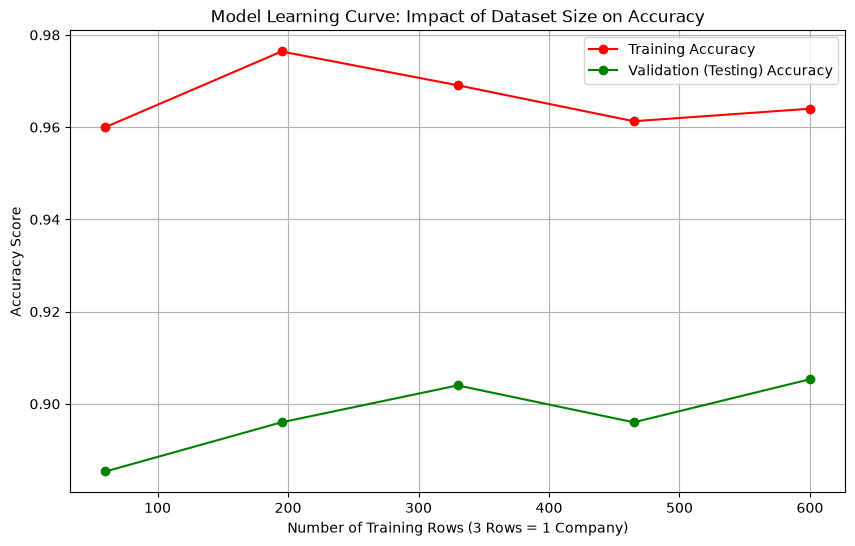

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, GroupKFold
import xgboost as xgb
import pandas as pd

# Load your dataset first so Python knows what 'df' means!
df = pd.read_csv("final_dataset.csv")
# 1. Define your features (X), target labels (y), and company groups
# (Replace these with your actual dataframe column names)
X = df[['clean_domain_similarity', 'search_position', 'is_socialmedia', 'acronym_match']]
y = df['is_correct']
groups = df['query_name']  # Crucial for GroupKFold!

# 2. Set up your model and your GroupKFold strategy
model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
cv = GroupKFold(n_splits=5)

# 3. Calculate cross-validated scores across different dataset sizes
# train_sizes=np.linspace(0.1, 1.0, 5) tells it to test at 10%, 32.5%, 55%, 77.5%, and 100% of data
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X,
    y=y,
    groups=groups,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

# 4. Calculate the average scores across the cross-validation folds
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# 5. Plot the learning curve chart
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training Accuracy')
plt.plot(train_sizes, val_mean, 'o-', color='g', label='Validation (Testing) Accuracy')

plt.title('Model Learning Curve: Impact of Dataset Size on Accuracy')
plt.xlabel('Number of Training Rows (3 Rows = 1 Company)')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.legend(loc='best')
plt.show()